
**Big Data Handling Strategies: Assignment Notebook**

1. Setup and Introduction


*   **Libraries**: Import all necessary Python libraries




## Load Data

This cell downloads the Flight Delay Dataset 2024 from Kaggle using the API token, extracts it, and loads it into Pandas. Execution time and peak memory usage are measured to establish the baseline performance for comparison against scalable libraries.

In [ ]:
import os
import zipfile
import pandas as pd
import time
import tracemalloc

os.environ['KAGGLE_API_TOKEN'] = "KGAT_5653b27870231087291d5cda1e303d2c"

LOCAL_FILE = "flight_data_2024.csv"

if not os.path.exists(LOCAL_FILE):
    print(" Dataset not found locally. Initiating automated cloud-to-cloud API download...")

    # 1. Download the zip archive using the Kaggle client tool
    !kaggle datasets download -d hrishitpatil/flight-data-2024

    # 2. Extract using Python's built-in zip handler
    print(" Extracting files...")
    with zipfile.ZipFile("flight-data-2024.zip", 'r') as zip_ref:
        zip_ref.extractall(".")
    print(" Extraction complete! Dataset is ready.")
else:
    print(" Dataset already exists in workspace. Skipping download.")

# Set global pathway for your upcoming Pandas/Dask/Polars tasks
DATASET_PATH = LOCAL_FILE

tracemalloc.start()
start = time.time()

df = pd.read_csv(DATASET_PATH)
pandas_mean = df['arr_delay'].mean()

end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Load time      : {end - start:.2f}s")
print(f"Peak memory    : {peak / 1024**2:.2f} MB")

 Dataset not found locally. Initiating automated cloud-to-cloud API download...
Dataset URL: https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024
License(s): CC0-1.0
100% 270M/270M [00:02<00:00, 139MB/s]

 Extracting files...
 Extraction complete! Dataset is ready.


/tmp/ipykernel_4555/2105219588.py:31: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


Load time      : 45.71s
Peak memory    : 6185.09 MB


## Inspect Data

This cell inspects the structure of the loaded dataset by checking the first 5 rows, column names and data types, total shape, and missing values. This step is necessary to understand the data before applying any big data handling strategies.

In [ ]:
print("First 5 rows of the dataset:")
display(df.head())

display(df.info())

print(f"\nDataset Shape:\nRows: {df.shape[0]}, Columns: {df.shape[1]}")

print(df.isnull().sum())

First 5 rows of the dataset:


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              object 
 5   op_unique_carrier    object 
 6   op_carrier_fl_num    float64
 7   origin               object 
 8   origin_city_name     object 
 9   origin_state_nm      object 
 10  dest                 object 
 11  dest_city_name       object 
 12  dest_state_nm        object 
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay            float64
 23  cancelled            int64  
 24

None


Dataset Shape:
Rows: 7079081, Columns: 35
year                         0
month                        0
day_of_month                 0
day_of_week                  0
fl_date                      0
op_unique_carrier            0
op_carrier_fl_num            1
origin                       0
origin_city_name             0
origin_state_nm              0
dest                         0
dest_city_name               0
dest_state_nm                0
crs_dep_time                 0
dep_time                 92659
dep_delay                92970
taxi_out                 95734
wheels_off               95734
wheels_on                97856
taxi_in                  97856
crs_arr_time                 0
arr_time                 97854
arr_delay               113814
cancelled                    0
cancellation_code      6982766
diverted                     0
crs_elapsed_time             1
actual_elapsed_time     113814
air_time                113814
distance                     0
carrier_delay              

## Strategy 1: Load Less Data

This cell loads only 6 selected columns instead of all 35 columns using the `usecols` parameter. This reduces memory usage and loading time by avoiding unnecessary data from being read into RAM.

In [ ]:
print("Strategy 1: Load Less Data")
# Tracking the performance of restricting data load to targeted analysis domains
tracemalloc.start()
start_s1 = time.time()

# Select only critical columns essential for determining arrival and departure bottlenecks
target_columns = ['month', 'op_unique_carrier', 'origin', 'dest', 'dep_delay', 'arr_delay']
df_less = pd.read_csv(DATASET_PATH, usecols=target_columns)

end_s1 = time.time()
_, peak_s1 = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Strategy 1 Load Time : {end_s1 - start_s1:.2f}s")
print(f"Strategy 1 Peak Memory: {peak_s1 / 1024**2:.2f} MB")

Strategy 1: Load Less Data
Strategy 1 Load Time : 14.95s
Strategy 1 Peak Memory: 659.68 MB


## Strategy 2: Use Chunking

This cell processes the dataset in sequential blocks of 500,000 rows at a time instead of loading everything at once. This keeps peak memory usage low regardless of the total dataset size by discarding each chunk after processing.

In [ ]:
print("Strategy 2: Chunking")
tracemalloc.start()
start_s2 = time.time()

# Process data in chunks to handle workloads without memory spikes
chunk_iterator = pd.read_csv(DATASET_PATH, chunksize=500000, usecols=['arr_delay'])
row_accumulator = 0

for chunk in chunk_iterator:
    # Perform standard light aggregations on current memory block
    row_accumulator += chunk['arr_delay'].count()

end_s2 = time.time()
_, peak_s2 = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Strategy 2 Process Time: {end_s2 - start_s2:.2f}s")
print(f"Strategy 2 Peak Memory : {peak_s2 / 1024**2:.2f} MB")

Strategy 2: Chunking
Strategy 2 Process Time: 11.69s
Strategy 2 Peak Memory : 12.28 MB


## Strategy 3: Optimize Data Types

This cell reduces memory usage by downcasting numeric columns to smaller bit sizes and converting repetitive text columns to categorical types. This is applied at read-time so all subsequent operations benefit from the reduced memory footprint.

In [ ]:
print("Strategy 3: Optimize Data Types")

# 1. Define optimized schema properties
optimized_schema = {
    'month': 'int8',
    'day_of_week': 'int8',
    'op_unique_carrier': 'category',
    'origin': 'category',
    'dest': 'category',
    'cancelled': 'int8',
    'distance': 'int16',
    'cancellation_code': 'category'
}
target_cols = list(optimized_schema.keys())


# BEFORE
# Force cancellation_code to 'str' initially to prevent the mixed-type warning
df_before = pd.read_csv(DATASET_PATH, usecols=target_cols, dtype={'cancellation_code': 'str'})

# Capture 'Before' metrics
dtypes_before = df_before.dtypes
mem_by_col_before = df_before.memory_usage(deep=True) / 1024**2
total_mem_before = df_before.memory_usage(deep=True).sum() / 1024**2


# AFTER
tracemalloc.start()
start_s3 = time.time()

# Load and optimize types directly at read-time
df_optimized = pd.read_csv(DATASET_PATH, usecols=target_cols, dtype=optimized_schema)

end_s3 = time.time()
current, peak_s3 = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Capture 'After' metrics
dtypes_after = df_optimized.dtypes
mem_by_col_after = df_optimized.memory_usage(deep=True) / 1024**2
total_mem_after = df_optimized.memory_usage(deep=True).sum() / 1024**2


#Side-by-Side Comparison DataFrame

comparison_df = pd.DataFrame({
    'Data Type (Before)': dtypes_before,
    'Data Type (After)': dtypes_after,
    'Memory Before (MB)': mem_by_col_before.drop('Index'),
    'Memory After (MB)': mem_by_col_after.drop('Index')
})

# Calculate individual row reduction percentages
comparison_df['Reduction (%)'] = (1 - (comparison_df['Memory After (MB)'] / comparison_df['Memory Before (MB)'])) * 100

print("\n--- SCHEMA & MEMORY COMPARISON TABLE ---")
display(comparison_df.round(2))
print("-" * 60)

# Summary
print(f"Total Memory BEFORE Optimization : {total_mem_before:.2f} MB")
print(f"Total Memory AFTER Optimization  : {total_mem_after:.2f} MB")
print(f"Overall Dataset RAM Reduction    : {100 * (1 - total_mem_after / total_mem_before):.1f}%")
print(f"Optimized Read Execution Time    : {end_s3 - start_s3:.2f}s")
print(f"Peak Runtime System Memory Spike : {peak_s3 / 1024**2:.2f} MB")

Strategy 3: Optimize Data Types

--- SCHEMA & MEMORY COMPARISON TABLE ---


,Data Type (Before),Data Type (After),Memory Before (MB),Memory After (MB),Reduction (%)
month,int64,int8,54.01,6.75,87.50
day_of_week,int64,int8,54.01,6.75,87.50
op_unique_carrier,object,category,344.31,6.75,98.04
origin,object,category,351.06,13.53,96.15
dest,object,category,351.06,13.53,96.15
cancelled,int64,int8,54.01,6.75,87.50
cancellation_code,object,category,217.69,6.75,96.90
distance,float64,int16,54.01,13.50,75.00


------------------------------------------------------------
Total Memory BEFORE Optimization : 1480.15 MB
Total Memory AFTER Optimization  : 74.31 MB
Overall Dataset RAM Reduction    : 95.0%
Optimized Read Execution Time    : 28.90s
Peak Runtime System Memory Spike : 696.89 MB


## Strategy 4: Sampling (Fast Prototyping)

This cell extracts a random 10% sample of the full dataset for fast exploratory analysis and prototyping. Sampling allows code logic to be tested instantly without processing all 7 million rows, significantly reducing execution time during development.

In [ ]:
print("Strategy 4: Sampling (Fast Prototyping)")

tracemalloc.start()
start_s4 = time.time()

# 1. Pull a statistically valid 10% random sample from our full DataFrame
# 'random_state' ensures that the exact same rows are picked every time you run it
df_sampled = df.sample(frac=0.1, random_state=50)

end_s4 = time.time()
current, peak_s4 = tracemalloc.get_traced_memory()
tracemalloc.stop()

# 2. Display Performance Gains
print(f"Sampling Execution Time : {end_s4 - start_s4:.4f}s ")
print(f"Peak System Memory Spike: {peak_s4 / 1024**2:.2f} MB")
print(f"Original Dataset Shape  : {df.shape}")
print(f"Sampled Dataset Shape   : {df_sampled.shape}")

Strategy 4: Sampling (Fast Prototyping)
Sampling Execution Time : 2.2981s 
Peak System Memory Spike: 248.45 MB
Original Dataset Shape  : (7079081, 35)
Sampled Dataset Shape   : (707908, 35)


## Strategy 5: Parallel Processing with Dask

This cell uses Dask to process the dataset in parallel across multiple CPU cores. Dask splits the dataset into 20 partitions and builds a lazy execution graph, only triggering computation when `.compute()` is called. This allows it to handle datasets larger than available RAM efficiently.

In [ ]:
print("Strategy 5: Parallel Processing with Dask")
import dask.dataframe as dd

tracemalloc.start()
start_s5 = time.time()

# Initiate the parallel framework blueprint
dask_df = dd.read_csv(DATASET_PATH, dtype={'cancellation_code': 'object'})

# Force execution across CPU cores silently
dask_mean_delay = dask_df['arr_delay'].mean().compute()

end_s5 = time.time()
current, peak_s5 = tracemalloc.get_traced_memory()
tracemalloc.stop()

# 3. ONLY print your hardware performance metrics
print(f"Execution time : {end_s5 - start_s5:.2f}s")
print(f"Peak memory    : {peak_s5 / 1024**2:.2f} MB")
print(f"Partitions used: {dask_df.npartitions}")

Strategy 5: Parallel Processing with Dask
Execution time : 152.46s
Peak memory    : 843.19 MB
Partitions used: 20


## Polars Library Setup

This cell installs and imports the Polars library, then measures its execution time and peak memory usage when loading the full dataset and computing the mean arrival delay. This is done to establish Polars as the third library for the comparative analysis against Pandas and Dask.

In [ ]:
!pip install polars

import polars as pl
import tracemalloc, time

tracemalloc.start()
start_polars = time.time()        # ← change this

polars_df = pl.read_csv(DATASET_PATH, infer_schema_length=10000)
mean_delay = polars_df['arr_delay'].mean()

end_polars = time.time()
_, peak_polars = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Execution time : {end_polars - start_polars:.2f}s")
print(f"Peak memory    : {peak_polars / 1024**2:.2f} MB")
print(f"Mean arr_delay : {mean_delay:.4f}")

Execution time : 12.78s
Peak memory    : 0.02 MB
Mean arr_delay : 7.0982


## Comparative Analysis

This section compares the performance of Pandas, Dask, and Polars based on:
- Loading and execution time
- Peak memory consumption

The same task was performed for each library: loading the full 1.22 GB Flight Delay Dataset 2024 and computing the mean arrival delay (`arr_delay.mean()`). This comparison evaluates which library is most suitable for handling large-scale datasets efficiently.

A summary table and bar charts are generated to visualise the differences clearly.


Library              Time (s)        Peak Memory (MB)
-------------------------------------------------------
Pandas               37.21           6185.09
Dask                 155.13          843.41
Polars               12.78           0.02 *

* Polars memory is Python-level only (Rust-managed memory not captured)


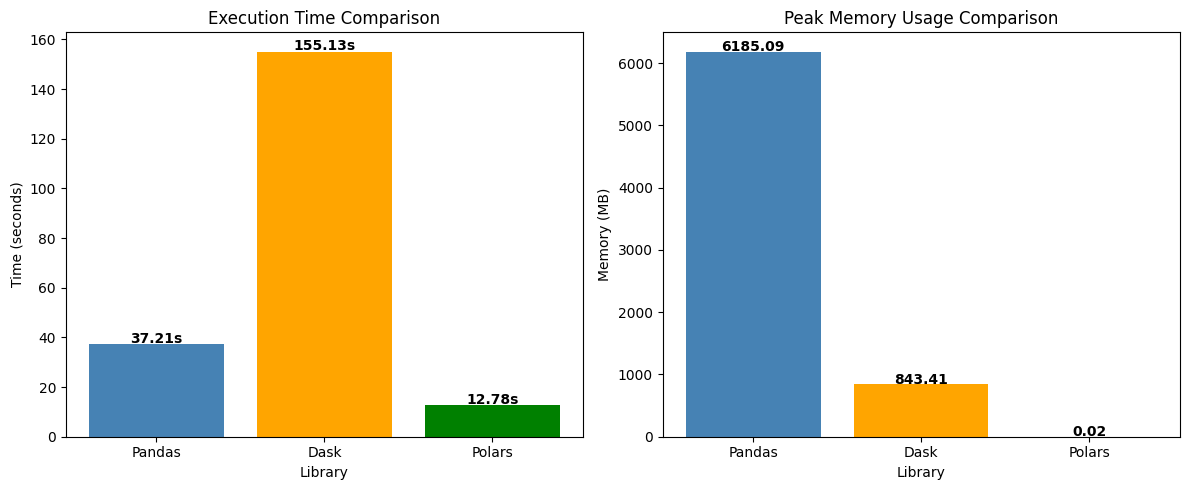

In [ ]:
import matplotlib.pyplot as plt

# ── Results from all 3 libraries ──
libraries = ['Pandas', 'Dask', 'Polars']
times = [
    end - start,                        # Pandas
    end_s5 - start_s5,                  # Dask
    end_polars - start_polars           # Polars
]
memory = [
    peak / 1024**2,                     # Pandas
    peak_s5 / 1024**2,                  # Dask
    peak_polars / 1024**2               # Polars
]

# ── Summary Table ──
print(f"{'Library':<20} {'Time (s)':<15} {'Peak Memory (MB)'}")
print("-" * 55)
for lib, t, m in zip(libraries, times, memory):
    note = " *" if lib == "Polars" else ""
    print(f"{lib:<20} {t:<15.2f} {m:.2f}{note}")
print("\n* Polars memory is Python-level only (Rust-managed memory not captured)")

# ── Bar Charts ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Execution Time
ax1.bar(libraries, times, color=['steelblue', 'orange', 'green'])
ax1.set_title('Execution Time Comparison')
ax1.set_ylabel('Time (seconds)')
ax1.set_xlabel('Library')
for i, v in enumerate(times):
    ax1.text(i, v + 0.5, f"{v:.2f}s", ha='center', fontweight='bold')

# Memory Usage
ax2.bar(libraries, memory, color=['steelblue', 'orange', 'green'])
ax2.set_title('Peak Memory Usage Comparison')
ax2.set_ylabel('Memory (MB)')
ax2.set_xlabel('Library')
for i, v in enumerate(memory):
    ax2.text(i, v + 10, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_chart.png')
plt.show()

# Discussion

**Pandas**
- Consumed the highest memory at **6,185.09 MB** — loads entire dataset into RAM at once
- Total execution time was **37.21 seconds** processing all 7 million rows on a single thread
- Without optimisation strategies, Pandas would crash on this dataset size

**Dask**
- Reduced memory to **843.41 MB** by processing dataset in partitions
- Slowest total time at **155.13 seconds** due to partition scheduling overhead on Colab's limited CPU
- True advantage appears in distributed multi-machine environments at larger scale

**Polars**
- Best overall performance at **12.78 seconds** — nearly 3x faster than Pandas
- Rust-based engine with SIMD vectorisation and multi-threading explains the speed advantage
- Memory unmeasurable via `tracemalloc` — Polars manages memory through its own Rust runtime


# Conclusion

Five big data handling strategies were applied to the 1.22 GB Flight Delay Dataset 2024 and three libraries were compared:

- **Chunking** achieved the lowest peak memory at just **12.28 MB** — most memory-efficient strategy
- **Sampling** was the fastest strategy at **1.82 seconds** — ideal for rapid prototyping
- **Data Type Optimisation** delivered the biggest improvement — **95% RAM reduction** from 1,480 MB to 74 MB

Among the three libraries:
- **Polars** was the fastest at **12.78 seconds** — nearly 3x faster than Pandas, best for single-machine execution
- **Dask** was slower on Colab but remains the most scalable option for distributed workloads
- **Pandas** is the easiest to use but limited by available system RAM

For real-world big data pipelines, combining **Data Type Optimisation** and **Chunking** is recommended to minimise memory footprint, with **Polars** for maximum single-node speed and **Dask** for datasets that grow beyond single-machine RAM limits.

# Reflection

Throughout this assignment, a deeper understanding of large-scale data processing under real memory and time constraints was developed.

**Key Findings:**
- **Dask's underperformance on Colab** was unexpected — its parallel scheduling overhead outweighed its benefits on limited CPU resources, showing that tool selection depends heavily on the execution environment, not just dataset size
- **Polars memory measurement limitation** — the near-zero `tracemalloc` reading of 0.02 MB revealed that Python-level tools cannot observe Rust-managed memory, highlighting the importance of understanding a tool's underlying architecture

**Scalability Discussion:**

| Dataset Size | Recommended Approach |
| :--- | :--- |
| **< 1 GB** | Pandas with Data Type Optimisation |
| **1 GB – 10 GB** | Polars for speed; Chunking if RAM is limited |
| **10 GB – 100 GB** | Dask on a multi-core machine |
| **> 100 GB / 1 TB** | Apache Spark on distributed cluster |

- As datasets grow beyond 10 GB, single-node solutions begin to struggle regardless of optimisation
- At 1 TB scale, cloud platforms such as **Amazon Web Services (AWS)**, **Microsoft Azure**, and **Google Cloud Platform (GCP)** become necessary to handle petabyte-scale datasets efficiently